In [86]:
import requests
import zipfile
import pathlib
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

from torchmetrics.classification import Accuracy
from tqdm.auto import tqdm

In [87]:
root_dir = pathlib.Path("./data")
image_dir = root_dir / "pizza_steak_sushi"

In [88]:
if image_dir.is_dir():
    print("Already exists skipping...")
else:
    image_dir.mkdir(parents = True, exist_ok = True)

with open(root_dir / "content.zip", "wb") as dl:
    response = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    dl.write(response.content)

with zipfile.ZipFile(root_dir / "content.zip", "r") as zip_ref:
    zip_ref.extractall(image_dir)

Already exists skipping...


In [89]:
from PIL import Image

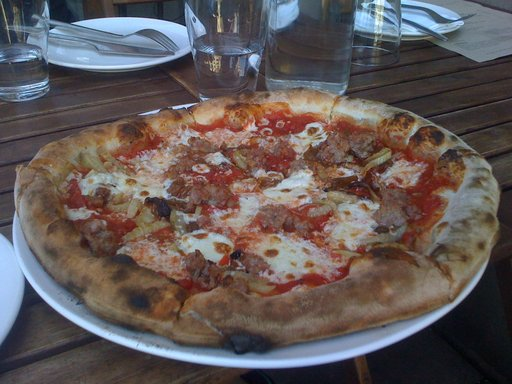

In [90]:
Image.open(image_dir / "train" / "pizza" / "5764.jpg")

In [91]:
def walk_thorugh_dir(dir_name):
    for root, dir, files in os.walk(dir_name):
     print(f"Root files: {root} | DirFiles: {dir} | Images: {len(files)}")

walk_thorugh_dir(image_dir)

Root files: data/pizza_steak_sushi | DirFiles: ['test', 'train'] | Images: 0
Root files: data/pizza_steak_sushi/test | DirFiles: ['steak', 'sushi', 'pizza'] | Images: 0
Root files: data/pizza_steak_sushi/test/steak | DirFiles: [] | Images: 19
Root files: data/pizza_steak_sushi/test/sushi | DirFiles: [] | Images: 31
Root files: data/pizza_steak_sushi/test/pizza | DirFiles: [] | Images: 25
Root files: data/pizza_steak_sushi/train | DirFiles: ['steak', 'sushi', 'pizza'] | Images: 0
Root files: data/pizza_steak_sushi/train/steak | DirFiles: [] | Images: 75
Root files: data/pizza_steak_sushi/train/sushi | DirFiles: [] | Images: 72
Root files: data/pizza_steak_sushi/train/pizza | DirFiles: [] | Images: 78


In [92]:
image_path_list = list(image_dir.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

classes = random_image_path.parent.stem
# classes

img = Image.open(random_image_path)
# img

In [93]:
imgarray = np.asarray(img)
# imgarray

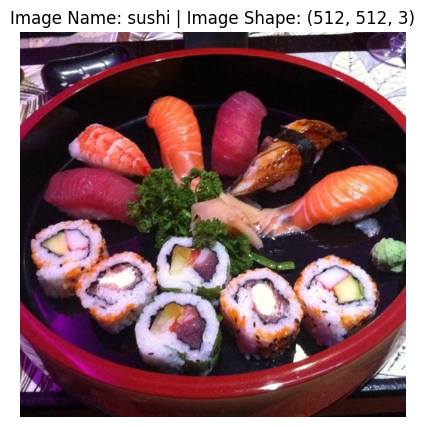

In [94]:
plt.figure(figsize = (10, 5))
plt.imshow(imgarray)
plt.title(f"Image Name: {str(classes)} | Image Shape: {imgarray.shape}")
# plt.inline(Flase)
plt.axis(False)
# plt.legend()
plt.show()

In [95]:
img_arrays = []

for img_path in image_path_list:
    # print(img_path)
    img = Image.open(img_path)
    img_array = np.asarray(img)
    img_class = img_path.parent.stem

    img_arrays.append((img_array, img_class))

In [96]:
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
import torchvision.transforms.v2 as transforms

In [97]:
transform = transforms.Compose([
    transforms.Resize(size=[64, 64]),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale = True)
])

In [98]:
transformed_img = transform(img)

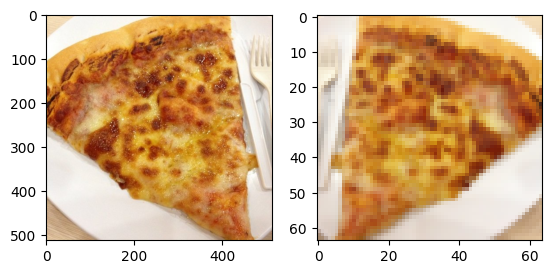

In [99]:
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(transformed_img.permute(1, 2, 0))

In [100]:
train_dir = image_dir / "train"
test_dir = image_dir / "test"

In [101]:
train_dataset =  datasets.ImageFolder(train_dir, transform = transform, target_transform = None)
test_dataset = datasets.ImageFolder(test_dir, transform = transform)

In [102]:
train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                  Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomHorizontalFlip(p=0.5)
                  ToImage()
                  ToDtype(scale=True)
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                  Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomHorizontalFlip(p=0.5)
                  ToImage()
                  ToDtype(scale=True)
            ))

In [103]:
classes = train_dataset.classes
classes

['pizza', 'steak', 'sushi']

In [104]:
test_dataset.classes

['pizza', 'steak', 'sushi']

In [105]:
train_dataset.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [106]:
train_loader = DataLoader(train_dataset,
                         shuffle = True,
                         batch_size = 32)

test_loader = DataLoader(test_dataset,
                        shuffle = False,
                        batch_size = 32)

In [107]:
image, target = next(iter(train_loader))

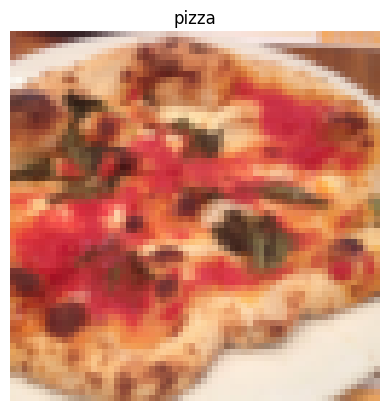

In [108]:
plt.imshow(image[0].permute(1, 2, 0))
plt.title(classes[target[0]])
plt.axis(False)
plt.show()

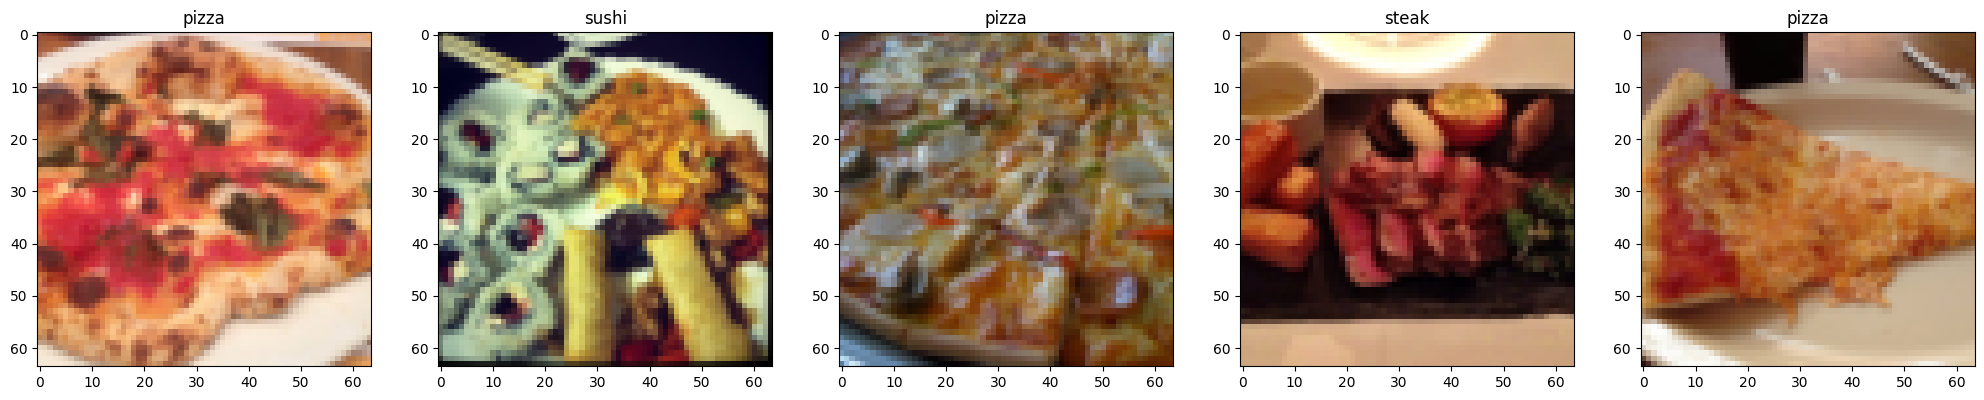

In [109]:
plt.figure(figsize = (25, 20))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(classes[target[i]])

In [110]:
def fetch_classes(dirname: str):
    classes = sorted(entry.name for entry in os.scandir(dirname) if dirname.is_dir())

    idx_classes = {k:i for i, k in enumerate(classes)}
    return classes, idx_classes

In [111]:
classes, idx_classes = fetch_classes(image_dir / "train")

idx_classes, classes

({'pizza': 0, 'steak': 1, 'sushi': 2}, ['pizza', 'steak', 'sushi'])

In [112]:
class CustomImageFolder(Dataset):
    def __init__(self, root: str = None, transform = None):
        super(CustomImageFolder, self).__init__()

        self.root = root
        self.annotation = list(self.root.glob('*/*.jpg'))
        self.classes, self.idx_classes = fetch_classes(root)
        self.transform  = transform
        self.samples = [
            (img_path, self.idx_classes[img_path.parent.stem])
            for img_path in self.annotation
            ]

    def __len__(self):
        return len(self.annotation)

    def __getitem__(self, index):
        image = Image.open(self.annotation[index]).convert("RGB")
        # self.samples.

        class_name = self.annotation[index].parent.stem
        class_idx = self.idx_classes[class_name]

        if self.transform:
            return self.transform(img), class_idx
        return img, class_idx

    def __repr__(self):
        return (f"CustomImageFolder \n   Number of Datapoints: {len(self.annotation)} \n"
        f"   Root Location: {self.root} \n"
        f"   Transforms: {self.transform}")
        

In [113]:
custom_train_dataset = CustomImageFolder(train_dir, transform)
custom_test_dataset = CustomImageFolder(test_dir, transform)

custom_train_dataset, custom_test_dataset

(CustomImageFolder 
    Number of Datapoints: 225 
    Root Location: data/pizza_steak_sushi/train 
    Transforms: Compose(
       Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomHorizontalFlip(p=0.5)
       ToImage()
       ToDtype(scale=True)
 ),
 CustomImageFolder 
    Number of Datapoints: 75 
    Root Location: data/pizza_steak_sushi/test 
    Transforms: Compose(
       Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomHorizontalFlip(p=0.5)
       ToImage()
       ToDtype(scale=True)
 ))

In [114]:
img_path, idx = custom_train_dataset.samples[10]
img_path 

PosixPath('data/pizza_steak_sushi/train/steak/1615395.jpg')

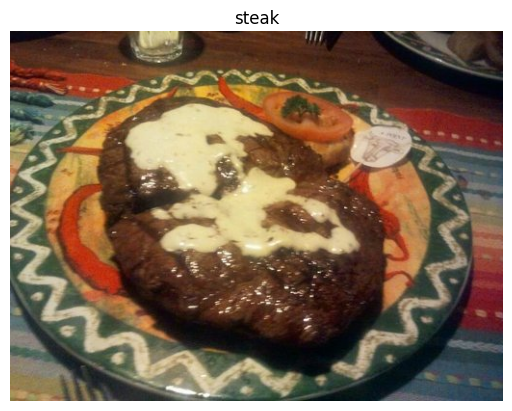

In [115]:
img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title(custom_train_dataset.classes[idx])
plt.show()

In [116]:
custom_train_loader = DataLoader(custom_train_dataset,
                                shuffle = True,
                                batch_size = 5)
custom_test_loader = DataLoader(custom_test_dataset,
                               shuffle = False,
                               batch_size = 5)

In [117]:
_img, _target = next(iter(custom_train_loader))

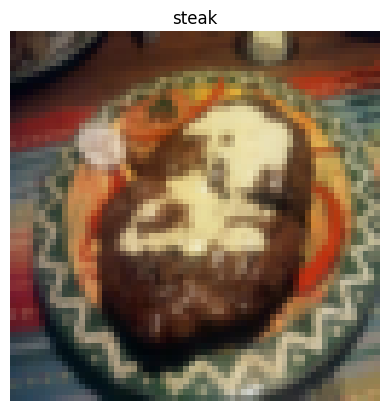

In [118]:
plt.imshow(_img[0].permute(1, 2, 0))
plt.title(custom_train_dataset.classes[_target[0]])
plt.axis(False)
plt.show()

In [119]:
64 * 64

4096

In [153]:
class FoodClassifierModel(torch.nn.Module):
    def __init__(self, in_features: int = 3, out_features: int = 3, hidden_units: int = 32,
                drop_units: int = 16):
        super(FoodClassifierModel, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.hidden_units = hidden_units 
        self.drop_units = drop_units

        self.convolutional_layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features,
                           out_channels = self.hidden_units,
                           padding = 0,
                           kernel_size = (3, 3),
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = (2, 2), stride = 2)
        )

        self.convolutional_layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.drop_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.drop_units,
                           out_channels = self.drop_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = (2, 2), stride = 2)
        )

        self.linear_layer = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.drop_units * 13 * 13,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.convolutional_layer1(x)
        # print(x.shape)
        x = self.convolutional_layer2(x)
        # print(x.shape)
        x = self.linear_layer(x)
        # print(x.shape)
        return x

In [154]:
device = "mps" if torch.mps.is_available() else "cpu"

In [155]:
device

'mps'

In [156]:
model = FoodClassifierModel().to(device)
model

FoodClassifierModel(
  (convolutional_layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (convolutional_layer2): Sequential(
    (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2704, out_features=3, bias=True)
  )
)

In [157]:
# with torch.inference_mode():
#     pred = model(image.to(device))

# pred

# image[0].shape

In [158]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-5)
accuracy = Accuracy(task = "multiclass", num_classes = 3).to(device)

In [159]:
total_epochs = 100

for epoch in tqdm(range(total_epochs)):
    model.train()
    accuracy.reset()

    running_train_acc, running_test_acc = 0.0, 0.0
    running_train_loss, running_test_loss = 0.0, 0.0

    for idx, (image, target) in enumerate(train_loader):
        # image, target = image.to(device), target.to(device)
        # print(f"Image Shape: {image.shape}")
        target_logits = model(image.to(device))
        # print(f"Logits Shape: {target_logits.shape}")
        # print(f"Target Shape: {target.shape}")

        loss = criterion(target_logits, target.to(device))
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        accuracy.update(target.to(device), target_logits.argmax(dim = 1))

    avg_running_train_loss = running_train_loss / len(train_loader)
    avg_running_train_acc = accuracy.compute().item()

    model.eval()
    accuracy.reset()
    
    with torch.inference_mode():
        for _image, _target in test_loader:
            test_target_logits = model(_image.to(device))
            test_loss = criterion(test_target_logits, _target.to(device))

            running_test_loss += test_loss.item()
            accuracy.update(_target.to(device), test_target_logits.argmax(dim = 1))

        avg_test_loss = running_test_loss / len(test_loader)
        avg_test_acc = accuracy.compute().item()

    if epoch % (total_epochs * 0.1) == 0:
        print(f"Training Loss: {avg_running_train_loss} | Training Accuracy: {avg_running_train_acc}")
        print(f"Testing Loss: {avg_test_loss} | Testing Accuracy: {avg_test_acc}")

  1%|▍                                          | 1/100 [00:00<00:45,  2.16it/s]

Training Loss: 1.1095409393310547 | Training Accuracy: 0.3199999928474426
Testing Loss: 1.1063530047734578 | Testing Accuracy: 0.2666666805744171


 11%|████▌                                     | 11/100 [00:04<00:37,  2.39it/s]

Training Loss: 0.8684188351035118 | Training Accuracy: 0.6311110854148865
Testing Loss: 1.1113059123357136 | Testing Accuracy: 0.4399999976158142


 21%|████████▊                                 | 21/100 [00:08<00:32,  2.39it/s]

...

 81%|██████████████████████████████████        | 81/100 [00:33<00:07,  2.41it/s]

Training Loss: 0.12335218299631379 | Training Accuracy: 0.9511111378669739
Testing Loss: 2.4356816609700522 | Testing Accuracy: 0.4933333396911621


 91%|██████████████████████████████████████▏   | 91/100 [00:37<00:03,  2.44it/s]

Training Loss: 0.2718591308221221 | Training Accuracy: 0.9555555582046509
Testing Loss: 3.589224656422933 | Testing Accuracy: 0.54666668176651


100%|█████████████████████████████████████████| 100/100 [00:41<00:00,  2.40it/s]


In [203]:
single_image, target = next(iter(test_loader))

with torch.inference_mode():
    # y_pred = model()
    # for image, taget in test_loader:
    y_logits = model(single_image.to(device))
    y_pred = y_logits.argmax(dim = 1)

# single_image[0]
# single_image[0]

classes[y_pred[27].item()], classes[target[27].item()]

('sushi', 'steak')